# LLM Smoke Test Results (GenerRNA + BiRNA-BERT)

This notebook documents the local end-to-end smoke test that proves LLM wiring before GPU cloud spend.

**Pipeline**

1. **GenerRNA** (`src/de_novo_hallucinations/gener_rna.py`) — native PyTorch micro-generation on CPU
   - 2 sequences, `temperature=1.0`, `top_k=250`, `max_new_tokens=64`
   - Output: `data/processed/de_novo/smoke/generated.fasta`
2. **BiRNA-BERT** (`src/validation_embedding/birna_embed.py`) — NUC (space-separated) tokenization
   - Output: `data/processed/validation_embedding/smoke/*.npy`, `manifest.jsonl`

**Pass criteria**

- FASTA has 2 records; every base is in `AUGC`
- Each `.npy` embedding is 3-D with hidden size 768
- `manifest.jsonl` has 2 JSON lines (one per sequence)

Re-run the pipeline: `bash scripts/generation/llm_smoke_test.sh` (first GenerRNA run downloads ~3.6 GB to `models/genererna/`).

In [1]:
import json
import re
import subprocess
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_engineering.paths import resolve_path

FASTA_PATH = resolve_path("data/processed/de_novo/smoke/generated.fasta")
EMBED_DIR = resolve_path("data/processed/validation_embedding/smoke")
MANIFEST_PATH = EMBED_DIR / "manifest.jsonl"
RNA_PATTERN = re.compile(r"^[AUGC]+$")

print(f"Project root: {PROJECT_ROOT}")
print(f"FASTA exists: {FASTA_PATH.exists()}")
print(f"Embedding dir exists: {EMBED_DIR.exists()}")

Project root: /Users/amierzuhri/arcblanc/Thermoswitches-MLBIO
FASTA exists: True
Embedding dir exists: True


## GenerRNA output

In [2]:
def parse_fasta(path: str | Path) -> list[tuple[str, str]]:
    """Parse a FASTA file into (header, sequence) records."""
    records = []
    header = None
    parts = []
    with Path(path).open() as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(parts)))
                header = line[1:]
                parts = []
            else:
                parts.append(line)
    if header is not None:
        records.append((header, "".join(parts)))
    return records


if not FASTA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {FASTA_PATH}. Run: bash scripts/generation/llm_smoke_test.sh"
    )

records = parse_fasta(FASTA_PATH)
rows = []
for header, sequence in records:
    seq = sequence.replace("T", "U").upper()
    counts = Counter(seq)
    rows.append(
        {
            "record_id": header,
            "length_nt": len(seq),
            "valid_rna": bool(RNA_PATTERN.match(seq)),
            "A": counts.get("A", 0),
            "U": counts.get("U", 0),
            "G": counts.get("G", 0),
            "C": counts.get("C", 0),
            "preview": seq[:60] + ("..." if len(seq) > 60 else ""),
        }
    )

fasta_df = pd.DataFrame(rows)
fasta_df

,record_id,length_nt,valid_rna,A,U,G,C,preview
0,sample_0,383,True,96,76,128,83,CUCCUACGGGAGGCAGCAGUGGGGAAUCUUGCGCAAUGGGCGAAAG...
1,sample_1,108,True,29,20,36,23,GGGGAACGUUGAAGACGACGACGUUGAUAGGCCGGGUGUGUAAGCG...


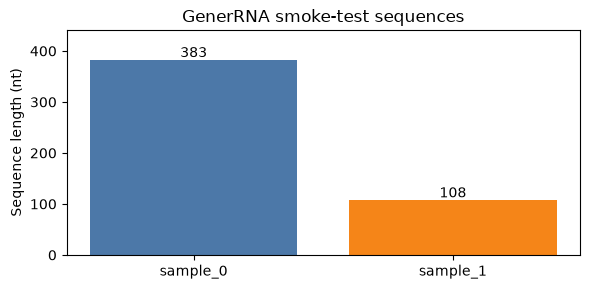

In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(fasta_df["record_id"], fasta_df["length_nt"], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Sequence length (nt)")
ax.set_title("GenerRNA smoke-test sequences")
ax.set_ylim(0, fasta_df["length_nt"].max() * 1.15)
for bar_i, (_, row) in enumerate(fasta_df.iterrows()):
    ax.text(
        bar_i, row["length_nt"] + 5, str(row["length_nt"]), ha="center", fontsize=10
    )
plt.tight_layout()
plt.show()

## Automated verification

In [4]:
verify_script = PROJECT_ROOT / "scripts" / "verify_llm_smoke_outputs.py"
result = subprocess.run(
    [sys.executable, str(verify_script)],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError("Smoke output verification failed")

[PASS] fasta record count — 2 records
[PASS] sample_0 valid RNA — CUCCUACGGGAGGCAGCAGUGGGGAAUCUUGCGCAAUGGG...
[PASS] sample_1 valid RNA — GGGGAACGUUGAAGACGACGACGUUGAUAGGCCGGGUGUG...
[PASS] npy file count — 2 files
[PASS] sample_0.npy hidden dim — (1, 385, 768)
[PASS] sample_1.npy hidden dim — (1, 110, 768)
[PASS] manifest.jsonl lines — 2 lines

All LLM smoke output checks passed.



## BiRNA-BERT embeddings

In [5]:
manifest_rows = []
with MANIFEST_PATH.open() as handle:
    for line in handle:
        manifest_rows.append(json.loads(line))

manifest_df = pd.DataFrame(manifest_rows)
manifest_df[["record_id", "tokenization", "model_id", "shape", "hidden_size"]]

,record_id,tokenization,model_id,shape,hidden_size
0,sample_0,NUC,buetnlpbio/birna-bert,"[1, 385, 768]",768
1,sample_1,NUC,buetnlpbio/birna-bert,"[1, 110, 768]",768


In [6]:
embedding_stats = []
for record_id in manifest_df["record_id"]:
    array = np.load(EMBED_DIR / f"{record_id}.npy")
    embedding_stats.append(
        {
            "record_id": record_id,
            "shape": tuple(array.shape),
            "seq_positions": array.shape[1],
            "hidden_dim": array.shape[2],
            "mean": float(array.mean()),
            "std": float(array.std()),
        }
    )

embed_df = pd.DataFrame(embedding_stats)
embed_df

,record_id,shape,seq_positions,hidden_dim,mean,std
0,sample_0,"(1, 385, 768)",385,768,0.000854,0.434466
1,sample_1,"(1, 110, 768)",110,768,0.000823,0.432109


In [7]:
# NUC tokenization adds [CLS]/[SEP] tokens → embedding positions = nt + 2
compare = fasta_df[["record_id", "length_nt"]].merge(
    embed_df[["record_id", "seq_positions"]], on="record_id"
)
compare["expected_positions"] = compare["length_nt"] + 2
compare["positions_match"] = compare["seq_positions"] == compare["expected_positions"]
compare

,record_id,length_nt,seq_positions,expected_positions,positions_match
0,sample_0,383,385,385,True
1,sample_1,108,110,110,True


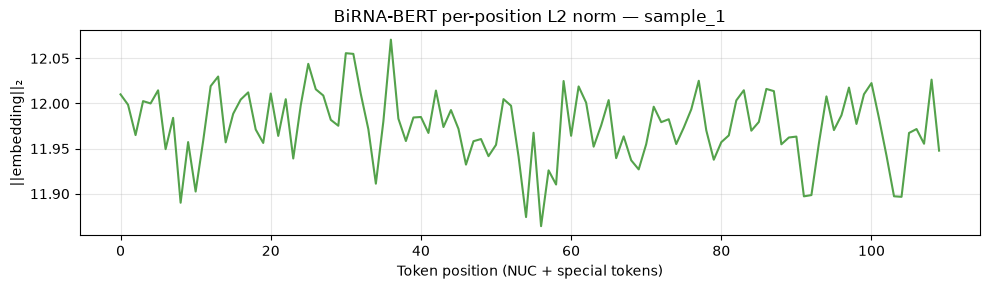

In [8]:
# Mean embedding magnitude per sequence position (shorter record for readability)
short_id = embed_df.loc[embed_df["seq_positions"].idxmin(), "record_id"]
short_array = np.load(EMBED_DIR / f"{short_id}.npy")[0]
position_norm = np.linalg.norm(short_array, axis=1)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(position_norm, color="#54A24B", linewidth=1.5)
ax.set_title(f"BiRNA-BERT per-position L2 norm — {short_id}")
ax.set_xlabel("Token position (NUC + special tokens)")
ax.set_ylabel("||embedding||₂")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Step | Status |
|------|--------|
| GenerRNA load + `load_state_dict` on CPU | OK |
| Micro-generation (2 × valid AUGC) | OK |
| BiRNA-BERT NUC tokenization + 768-d embeddings | OK |
| `.npy` + `manifest.jsonl` I/O | OK |

The same scripts run unchanged on a cloud GPU when CUDA is available (`CUDA_VISIBLE_DEVICES=0 bash scripts/generation/llm_smoke_test.sh`).